Dataset Shape: (505, 14)
Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

First 5 Rows:
      CRIM   ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  PTRATIO  \
0  0.02731  0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0     17.8   
1  0.02729  0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0     17.8   
2  0.03237  0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0     18.7   
3  0.06905  0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0     18.7   
4  0.02985  0.0   2.18     0  0.458  6.430  58.7  6.0622    3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   9.14  21.6  
1  392.83   4.03  34.7  
2  394.63   2.94  33.4  
3  396.90   5.33  36.2  
4  394.12   5.21  28.7  

Missing values: 0 total

Features Shape: (505, 13)
Target Shape  : (505,)
Target column : MEDV

Training Set: (404, 13)
Testing Set : (101, 13)

Model trained successfully.

  MODEL EVALUATION RESULTS
  MSE 

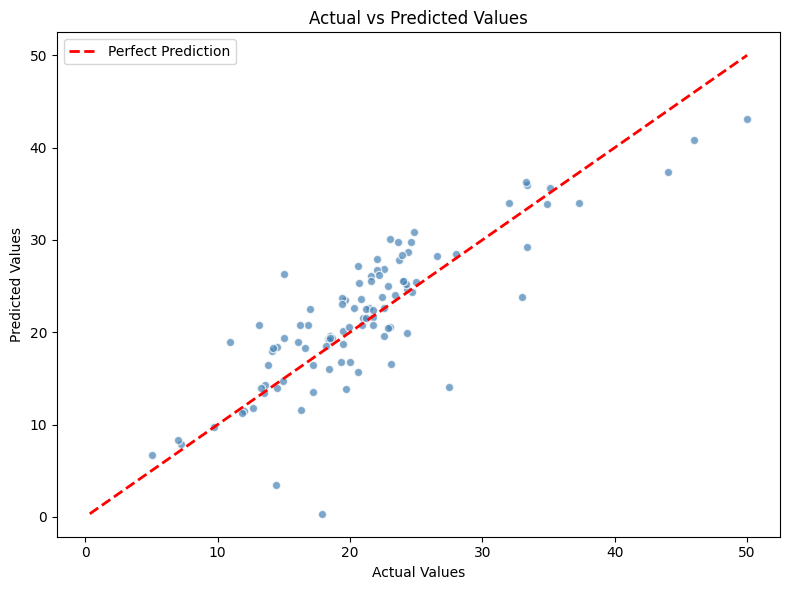

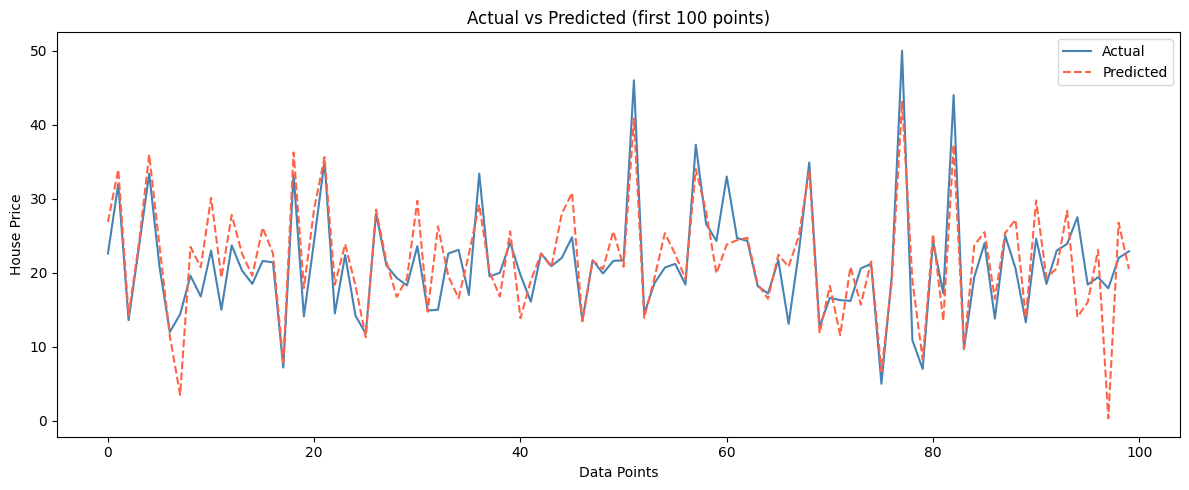

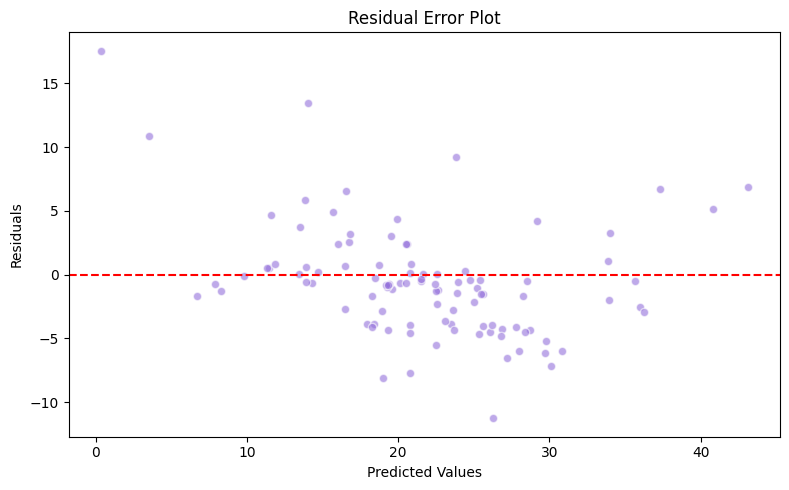

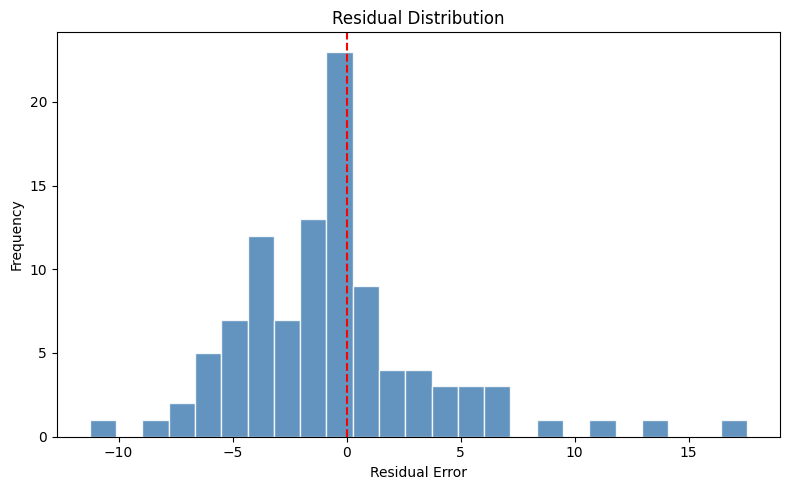


Regression Analysis Completed Successfully.


In [ ]:
"""
Regression Analysis
Codveda Data Analytics Internship - Level 2 Task 1
"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


FILE_PATH = r"C:\Users\ulya1\Desktop\Python\Codveda tasks\Data Set For Task\4) house Prediction Data Set.csv"

BOSTON_COLS = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']

df = pd.read_csv(
    FILE_PATH,
    sep=r'\s+',
    header=0, 
    names=BOSTON_COLS,
    skipinitialspace=True
)

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())


for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')


for col in df.columns:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values:", df.isnull().sum().sum(), "total")


X = df.iloc[:, :-1].copy().astype(float)
y = df.iloc[:, -1].copy().astype(float)

print("\nFeatures Shape:", X.shape)
print("Target Shape  :", y.shape)
print("Target column :", df.columns[-1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Set:", X_train.shape)
print("Testing Set :", X_test.shape)

model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel trained successfully.")

y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("\n" + "="*40)
print("  MODEL EVALUATION RESULTS")
print("="*40)
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R2   : {r2:.4f}")
print("="*40)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nModel Coefficients:")
print(coefficients.to_string(index=False))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white')

mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.tight_layout()
plt.show()

n = min(100, len(y_test))
plt.figure(figsize=(12, 5))
plt.plot(range(n), y_test.values[:n], label='Actual',    color='steelblue', lw=1.5)
plt.plot(range(n), y_pred[:n],        label='Predicted', color='tomato',    lw=1.5, ls='--')
plt.title("Actual vs Predicted (first 100 points)")
plt.xlabel("Data Points")
plt.ylabel("House Price")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color='mediumpurple', edgecolors='white')
plt.axhline(0, color='red', lw=1.5, ls='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Error Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(0, color='red', lw=1.5, ls='--')
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

print("\nRegression Analysis Completed Successfully.")


In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ulya1\Desktop\Python\Codveda tasks\Data Set For Task\4) house Prediction Data Set.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Dtypes:\n", df.dtypes)
print("\nHead:\n", df.head(2))

First 5 Rows:
  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391

Dataset Shape: (497472, 7)

Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-n

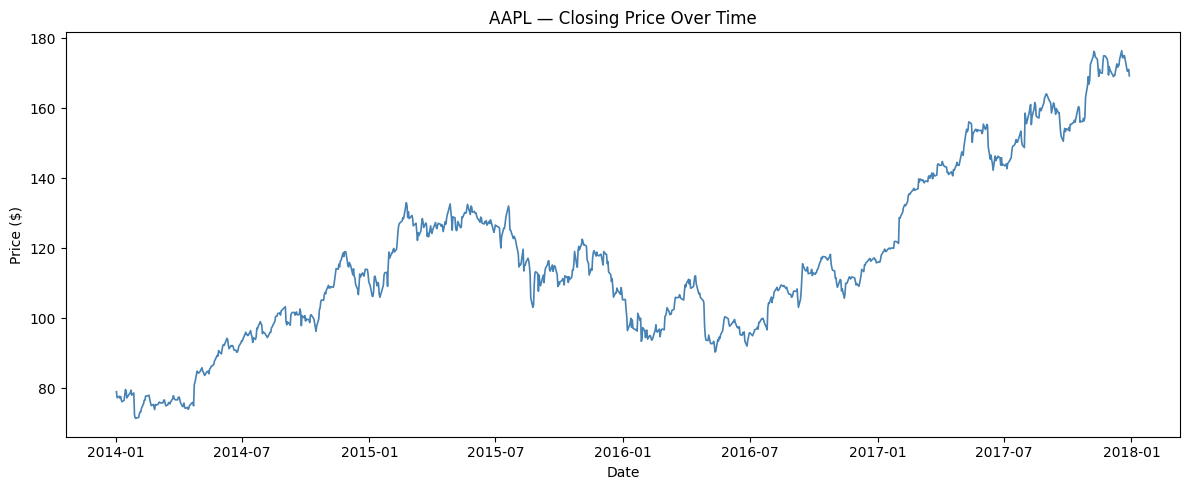

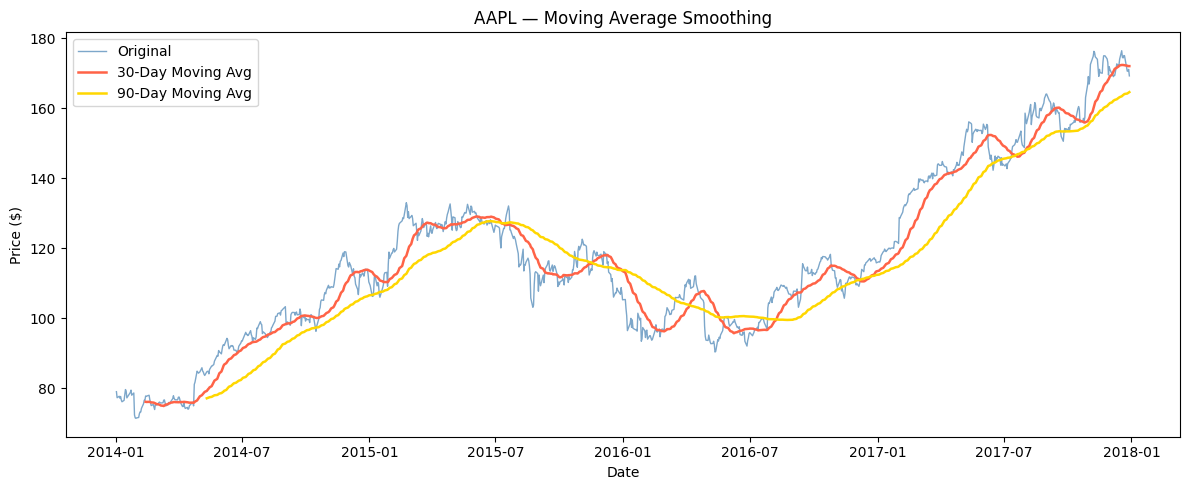

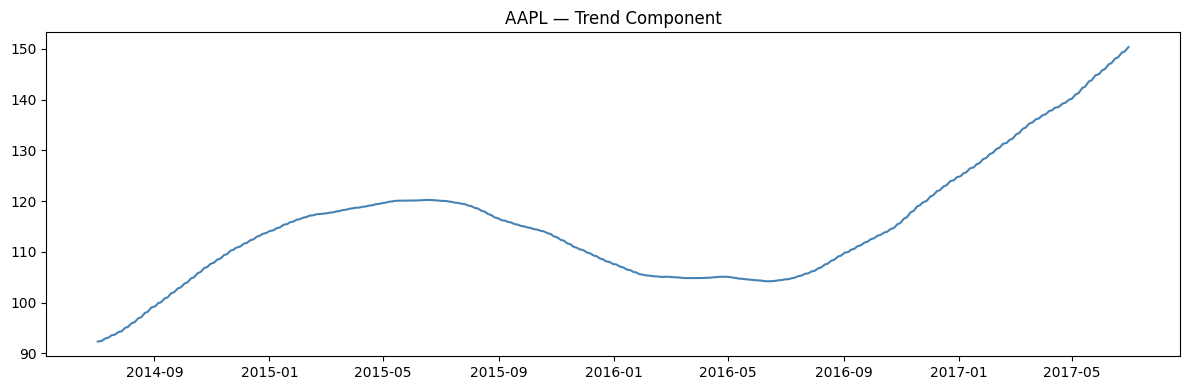

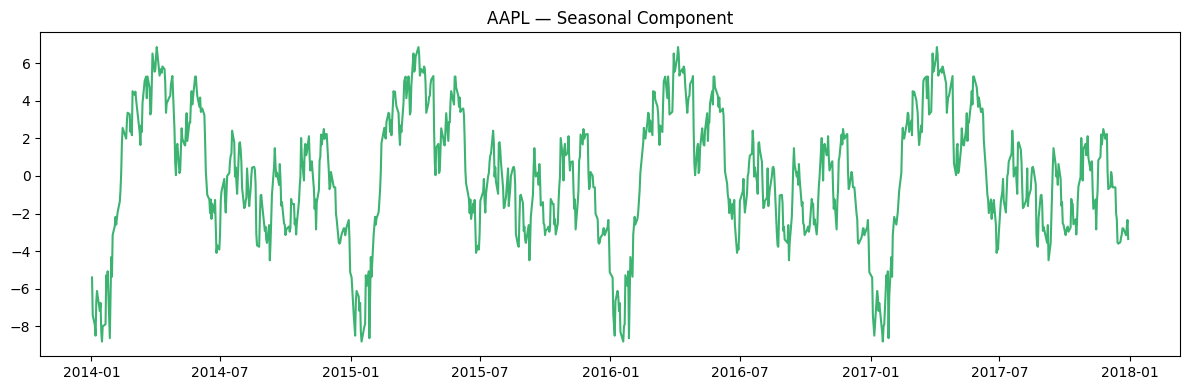

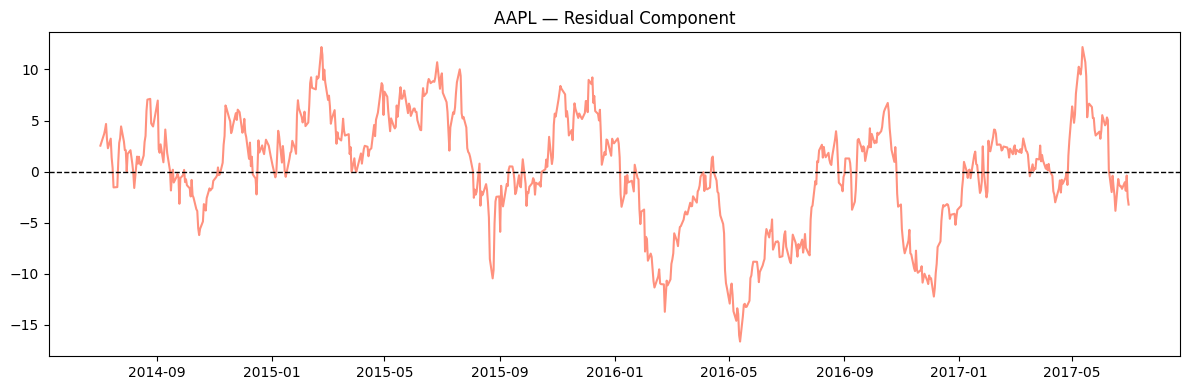

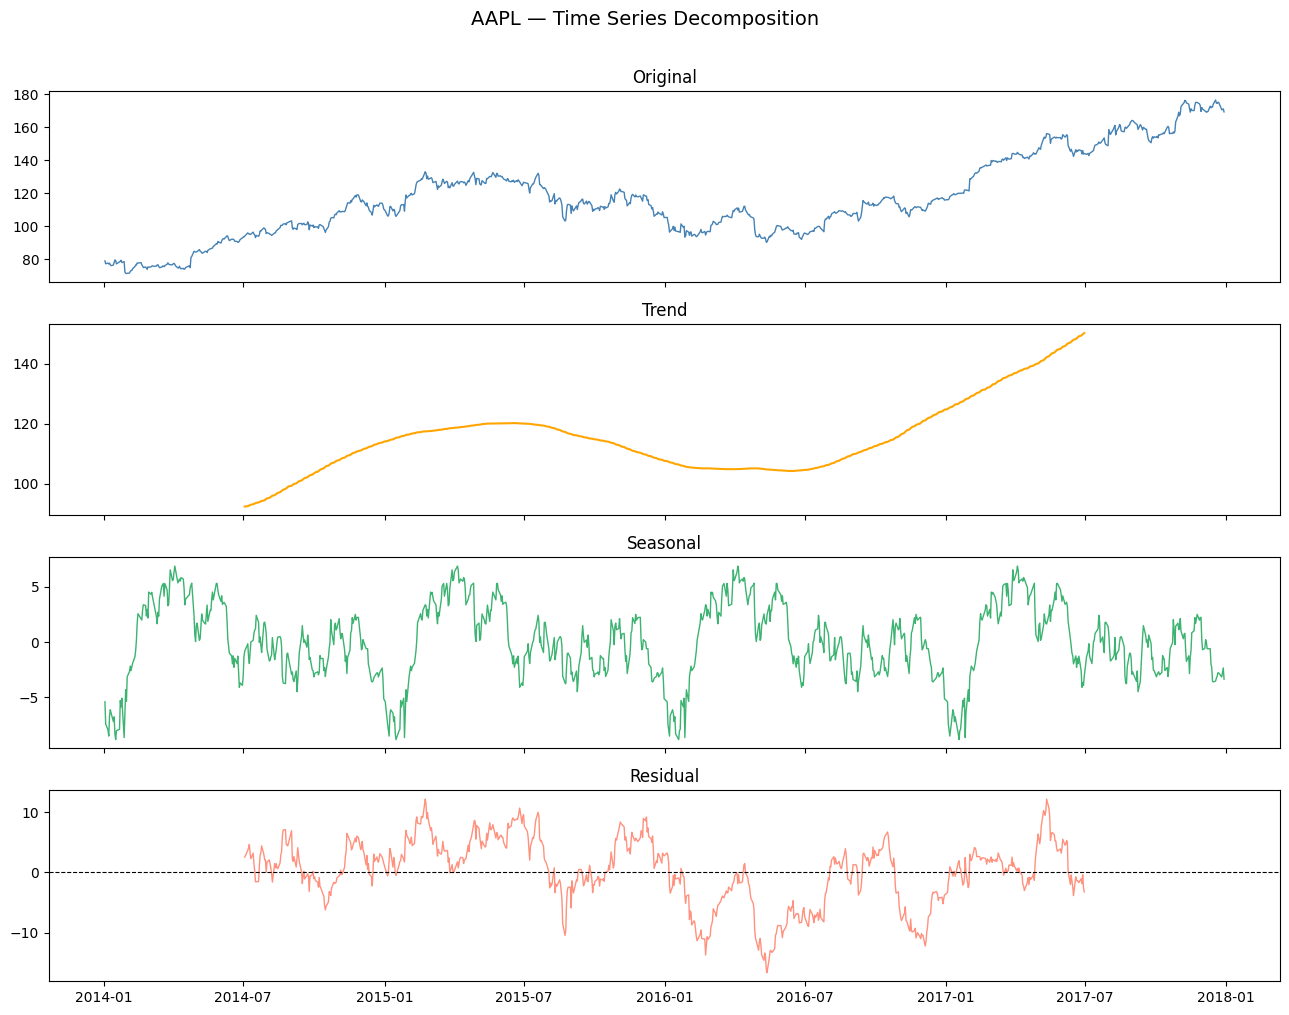


  AAPL — Summary Statistics
  Start Date     : 2014-01-02
  End Date       : 2017-12-29
  Minimum Price  : $71.40
  Maximum Price  : $176.42
  Average Price  : $116.84
  Total Return   : 114.2%

Time Series Analysis Completed Successfully.


In [20]:
"""
Time Series Analysis
Codveda Data Analytics Internship - Level 2 Task 2

Tools Used:
- Python
- Pandas
- Matplotlib
- Statsmodels
"""

# =========================
# 1. Import Libraries
# =========================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# =========================
# 2. Load Dataset
# =========================

df = pd.read_csv(r"C:\Users\ulya1\Desktop\Python\Codveda tasks\Data Set For Task\2) Stock Prices Data Set.csv")

# =========================
# 3. Dataset Overview
# =========================

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nDataset Information:")
print(df.info())

# =========================
# 4. Convert Date Column
# =========================

# Column name is lowercase 'date' (not 'Date')
df['date'] = pd.to_datetime(df['date'])

# =========================
# 5. Select One Symbol (e.g. AAPL)
# =========================

# The dataset contains multiple companies — selecting one
SYMBOL = 'AAPL'

df_symbol = df[df['symbol'] == SYMBOL].copy()
df_symbol.set_index('date', inplace=True)
df_symbol.sort_index(inplace=True)

print(f"\n{SYMBOL}: {len(df_symbol)} rows found.")
print(df_symbol.head())

# =========================
# 6. Target Column: close
# =========================

ts = df_symbol['close']

print("\nTime Series (close prices):")
print(ts.head())

# =========================
# 7. Plot: Closing Price Over Time
# =========================

plt.figure(figsize=(12, 5))
plt.plot(ts, color='steelblue', linewidth=1.2)
plt.title(f"{SYMBOL} — Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

# =========================
# 8. Moving Average
# =========================

ma_30 = ts.rolling(window=30).mean()
ma_90 = ts.rolling(window=90).mean()

plt.figure(figsize=(12, 5))
plt.plot(ts,    label='Original',          color='steelblue', linewidth=1,   alpha=0.7)
plt.plot(ma_30, label='30-Day Moving Avg', color='tomato',    linewidth=1.8)
plt.plot(ma_90, label='90-Day Moving Avg', color='gold',      linewidth=1.8)
plt.title(f"{SYMBOL} — Moving Average Smoothing")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9. Time Series Decomposition
# =========================

# Drop NaN values before decomposition
ts_clean = ts.dropna()

# period=252 → approximate number of trading days in a year
decomposition = seasonal_decompose(
    ts_clean,
    model='additive',
    period=252
)

# Trend Component
plt.figure(figsize=(12, 4))
plt.plot(decomposition.trend, color='steelblue')
plt.title(f"{SYMBOL} — Trend Component")
plt.tight_layout()
plt.show()

# Seasonal Component
plt.figure(figsize=(12, 4))
plt.plot(decomposition.seasonal, color='mediumseagreen')
plt.title(f"{SYMBOL} — Seasonal Component")
plt.tight_layout()
plt.show()

# Residual Component
plt.figure(figsize=(12, 4))
plt.plot(decomposition.resid, color='tomato', alpha=0.7)
plt.axhline(0, color='black', lw=1, ls='--')
plt.title(f"{SYMBOL} — Residual Component")
plt.tight_layout()
plt.show()

# =========================
# 10. All Components Combined
# =========================

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

axes[0].plot(ts_clean, color='steelblue', lw=1)
axes[0].set_title("Original")

axes[1].plot(decomposition.trend, color='orange', lw=1.5)
axes[1].set_title("Trend")

axes[2].plot(decomposition.seasonal, color='mediumseagreen', lw=1)
axes[2].set_title("Seasonal")

axes[3].plot(decomposition.resid, color='tomato', lw=1, alpha=0.7)
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_title("Residual")

plt.suptitle(f"{SYMBOL} — Time Series Decomposition", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# =========================
# 11. Summary Statistics
# =========================

print("\n" + "="*45)
print(f"  {SYMBOL} — Summary Statistics")
print("="*45)
print(f"  Start Date     : {ts.index.min().date()}")
print(f"  End Date       : {ts.index.max().date()}")
print(f"  Minimum Price  : ${ts.min():.2f}")
print(f"  Maximum Price  : ${ts.max():.2f}")
print(f"  Average Price  : ${ts.mean():.2f}")
print(f"  Total Return   : {((ts.iloc[-1]/ts.iloc[0])-1)*100:.1f}%")
print("="*45)

print("\nTime Series Analysis Completed Successfully.")


In [ ]:
import pandas as pd
df = pd.read_csv(r"C:\Users\ulya1\Desktop\Python\Codveda tasks\Data Set For Task\2) Stock Prices Data Set.csv")
print(df.columns.tolist())
print(df.head(2))